# Diabetes Data Exploration

In [1]:
# Import libraries
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [ ]:
# Load databset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path)

In [ ]:
print("Dataset Dimensions:", df.shape)
df.head()

In [ ]:
# Display Columns of Interest with Descriptions
columns_of_interest = {
    "SEQN": "Respondent sequence number",
    "DIQ010": "Doctor told you have diabetes",
    "DID040": "Age when first told you had diabetes",
    "DIQ160": "Ever told you have prediabetes",
    "DIQ180": "Had blood tested past three years",
    "DIQ050": "Taking insulin now",
    "DID060": "How long taking insulin",
    "DIQ060U": "Unit of measure (month/year)",
    "DIQ070": "Take diabetic pills to lower blood sugar"
}

df = df[list(columns_of_interest.keys())]
df.rename(columns=columns_of_interest, inplace=True)
df.head()

In [ ]:
# Frequency Tables
for col in df.columns[1:]:
    print(f"\n=== Frequency for {col} ===")
    print(df[col].value_counts(dropna=False).sort_index())

In [ ]:
# Missing Values Summary
print("\nMissing Values Summary:")
print(df.isna().sum())

In [ ]:
def mapping_status(data, mapping):
    labels = []
    for key in mapping:
        count_val = data.get(key, 0)
        labels.append(f"{mapping[key]}\n({count_val})")
    return (list(mapping.keys()), labels)

In [ ]:
# Visualizing Diabetes Diagnosis Distribution
counts = df['Doctor told you have diabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 3: "Borderline", 7: "Refused", 9: "Don't know"}

# Create a bar plot using matplotlib
plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetes Diagnosis Distribution (DIQ010)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/iabetes_diagnosis_distribution.png")
plt.show()

In [ ]:
# Graph for Age when first told you had diabetes
age_data = df['Age when first told you had diabetes'].dropna()
age_data_clean = age_data[(age_data >= 1) & (age_data <= 81)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(age_data_clean)
plt.title('Age Distribution for First Diabetes Diagnosis (DID040)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/age_distribution_diabetes_diagnosis.png")
plt.show()

In [ ]:
# Graph for Ever told you have prediabetes
counts = df['Ever told you have prediabetes'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Prediabetes Diagnosis Distribution (DIQ160)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/prediabetes_diagnosis_distribution.png")
plt.show()

In [ ]:
# Graph for Had blood tested past three years
counts = df['Had blood tested past three years'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Blood Test Distribution (DIQ180)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/blood_test_distribution.png")
plt.show()

In [ ]:
# Graph for Taking insulin now
counts = df['Taking insulin now'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Insulin Usage Distribution (DIQ050)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/insulin_usage_distribution.png")
plt.show()

In [ ]:
# Graph for How long taking insulin
insulin_duration = df['How long taking insulin'].dropna()
insulin_duration_clean = insulin_duration[(insulin_duration >= 1) & (insulin_duration <= 61)] # Ignore codes 666, 777, 999, .

plt.figure(figsize=(8, 6))
plt.hist(insulin_duration_clean)
plt.title('Duration of Insulin Usage (DID060)')
plt.xlabel('Duration (months)')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.savefig("img/insulin_duration_distribution.png")
plt.show()

In [ ]:
# Graph for Take diabetic pills to lower blood sugar
counts = df['Take diabetic pills to lower blood sugar'].value_counts().sort_index()
mapping = {1: "Yes", 2: "No", 7: "Refused", 9: "Don't know"}

plt.figure(figsize=(8, 6))
plt.bar(counts.index, counts.values)
plt.title('Diabetic Pills Usage Distribution (DIQ070)')
plt.xlabel('Response Code')
plt.ylabel('Count')

positions, tick_labels = mapping_status(counts, mapping)
plt.xticks(positions, tick_labels, rotation=0)

plt.tight_layout()
plt.savefig("img/diabetic_pills_distribution.png")
plt.show()

In [ ]:
# Save Cleaned Subset
df.to_csv("cleaned/diabetes_cleaned_subset.csv", index=False)

## Making Connections, Yippeeeeee

In [2]:
# code for combining all of the datasets into one

# import diabetes dataset
file_path = "diabetes_data/Diabetes_DIQ_L.xpt"
df, meta = pyreadstat.read_xport(file_path, encoding='cp1252')

# goes through all other files and merges them into the dataframe
dir = 'all_data'
ind = 0
for file in os.scandir(dir):
    if file.is_file():
        print(file)
        ind += 1
        newdf, meta = pyreadstat.read_xport(file, encoding='cp1252')
        df = df.merge(newdf, on="SEQN", how="left", copy=False, suffixes=[f'_x{ind}', f'_y{ind}'])

# create csv from combined dataframe
print(df.head())
df.to_csv('all_data.csv', index=False)

<DirEntry 'ACQ_L.xpt'>
<DirEntry 'AGP_L.xpt'>
<DirEntry 'ALQ_L.xpt'>
<DirEntry 'AUQ_L.xpt'>
<DirEntry 'BAX_L.xpt'>
<DirEntry 'BMX_L.xpt'>
<DirEntry 'BPQ_L.xpt'>
<DirEntry 'BPXO_L.xpt'>
<DirEntry 'CBC_L.xpt'>
<DirEntry 'DBQ_L.xpt'>
<DirEntry 'DEMO_L.xpt'>
<DirEntry 'DEQ_L.xpt'>
<DirEntry 'DPQ_L.xpt'>
<DirEntry 'ECQ_L.xpt'>
<DirEntry 'FASTQX_L.xpt'>
<DirEntry 'FERTIN_L.xpt'>
<DirEntry 'FNQ_L.xpt'>
<DirEntry 'FOLATE_L.xpt'>
<DirEntry 'FOLFMS_L.xpt'>
<DirEntry 'GHB_L.xpt'>
<DirEntry 'GLU_L.xpt'>
<DirEntry 'HDL_L.xpt'>
<DirEntry 'HEPA_L.xpt'>
<DirEntry 'HEPB_S_L.xpt'>
<DirEntry 'HEQ_L.xpt'>
<DirEntry 'HIQ_L.xpt'>
<DirEntry 'HOQ_L.xpt'>
<DirEntry 'HSCRP_L.xpt'>
<DirEntry 'HSQ_L.xpt'>
<DirEntry 'HUQ_L.xpt'>
<DirEntry 'IHGEM_L.xpt'>
<DirEntry 'IMQ_L.xpt'>
<DirEntry 'INQ_L.xpt'>
<DirEntry 'INS_L.xpt'>
<DirEntry 'KIQ_U_L.xpt'>
<DirEntry 'LUX_L.xpt'>
<DirEntry 'MCQ_L.xpt'>
<DirEntry 'OCQ_L.xpt'>
<DirEntry 'OHQ_L.xpt'>
<DirEntry 'PAQY_L.xpt'>
<DirEntry 'PAQ_L.xpt'>
<DirEntry 'PBCD_L.xpt'>
<DirEntr

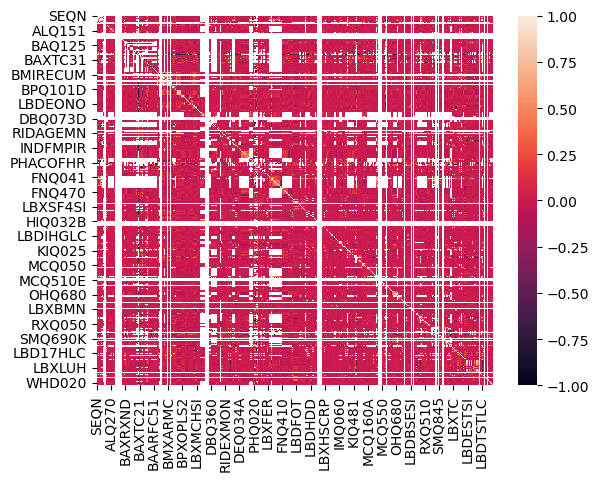

In [5]:
# import csv
df = pd.read_csv('all_data.csv')

df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)

# making correlation graph - only include numeric columns
corrmat = df_ml.corr(numeric_only=True)
round(corrmat, 2)
sns.heatmap(corrmat)
plt.show()

In [6]:
# gets lists of correlations to DIQ010 (diagnosed w/ diabetes) and the corresponding codes
correlations = corrmat['DIQ010'].dropna().tolist()[2:]
codes = corrmat['DIQ010'].dropna().keys().tolist()[2:]

print(correlations)
print(codes)

[0.5050867887972069, 0.005097991707587883, 0.10419337627490104, -0.009723990116876304, -0.07631305593026917, -0.051069420900464846, 0.002065057888218345, -0.03254183075576778, -0.010679608976526225, -0.03837249482348114, -0.06235235608991111, 0.05010812123699433, 0.022674188186198062, -0.1106321903226682, -0.018915021444364813, 0.030953203713738203, 0.11080481814092495, -0.14580278569616806, 0.12260895497673514, 0.017178993108630605, -0.14356756049987424, -0.10407326233599268, 0.053273901691207826, 0.07331325224079677, 0.029631733600838085, 0.08486147985743196, 0.07714791512771828, 0.04713930741558781, 0.013220412689089562, 0.0178421393632246, -0.06698783345824691, -0.015501249101457669, 0.01689317675756244, 0.17795043198213206, 0.13074409009212296, -0.11291342003201439, -0.05422752416049964, 0.07372858444938236, -0.04550851017604165, -0.2541211657249096, 0.05119313682134305, -0.018486846666163233, -0.07055318490255184, 0.022649605007689113, 0.09195187658823954, -0.11097788648298282, 0

In [23]:
# create a list of codes with decent correlation, format: (code, correlation)

filtCorrs = []
for i in range(len(correlations)):
    if correlations[i] > 0.15 or correlations[i] < -0.15:
        filtCorrs.append((codes[i], correlations[i]))

print(filtCorrs)
print(f'There are {len(filtCorrs)} codes with a correlation stronger than 0.15')

[('DIQ070', 0.5050867887972069), ('BAARFC11', 0.17795043198213206), ('BAXPF22', -0.2541211657249096), ('BAXTC32', 0.2853477113087644), ('BAARFC32', 0.30846757299551536), ('BAXTC41', 0.1651481121046766), ('BAXTC42', 0.15424625935166636), ('BMXWT', -0.22852099080333557), ('BMIHT', -0.15684977419778712), ('BMXBMI', -0.24545701660870484), ('BMXARML', -0.15562867607553688), ('BMXARMC', -0.2140917525997672), ('BMXWAIST', -0.2861023372289318), ('BMXHIP', -0.15300710323469635), ('BPQ020', 0.2679558769582363), ('BPQ080', 0.16936067813308928), ('BPQ101D', 0.22463394141912343), ('BPAOCSZ', -0.16018970906004584), ('BPXOSY1', -0.16406222876267873), ('BPXOSY2', -0.17309574150731474), ('BPXOSY3', -0.16571479524087557), ('LBXRDW', -0.1564153078539762), ('RIDAGEYR', -0.31487591593750835), ('DMDHHSIZ', 0.15804213602521006), ('PHACOFHR', -0.28004169278867297), ('PHACOFMN', 0.176720216771667), ('LBXFER', -0.20888810493365362), ('LBDFERSI', -0.20888810493365362), ('FNQ440', -0.273508939713992), ('FNQ490', 

Text(0, 0.5, 'Amount of Features')

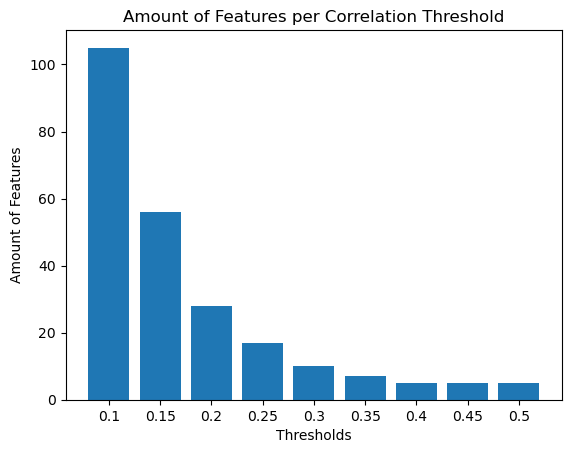

In [ ]:
# graph of the amount of features we can get with different correlation thresholds

amounts = []
thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

for t in thresholds:
    filtCorrsGraph = []
    for i in range(len(correlations)):
        if correlations[i] > t or correlations[i] < t*-1:
            filtCorrsGraph.append((codes[i], correlations[i]))
    amounts.append(len(filtCorrsGraph))


plt.bar(list(map(str, thresholds)), amounts, label = thresholds)
plt.title('Amount of Features per Correlation Threshold')
plt.xlabel('Thresholds')
plt.ylabel('Amount of Features')

In [12]:
codeDict = {
    "DIQ070": ("Diabetes", "Take diabetic pills to lower blood sugar"),
    "BAXMSTAT": ("Balance", "MRT exam status"),
    "BAX5STAT": ("Balance", "Eligibility for Condition 5"),
    "BAARFC11": ("Balance", "MRT cond. 1, trial 1, reason stopped"),
    "BAXPF12": ("Balance", "MRT cond. 1, trial 2, eyes open"),
    "BAXTC12": ("Balance", "MRT cond. 1, trial 2, time"),
    "BAARFC12": ("Balance", "MRT cond. 1, trial 2, reason stopped"),
    "BAXPF22": ("Balance", "MRT cond. 2, trial 2, eyes closed"),
    "BAXTC22": ("Balance", "MRT cond. 2, trial 2, time"),
    "BAARFC31": ("Balance", "MRT cond. 3, trial 1, reason stopped"),
    "BAXTC32": ("Balance", "MRT cond. 3, trial 2, time"),
    "BAARFC32": ("Balance", "MRT cond. 3, trial 2, reason stopped"),
    "BAXTC41": ("Balance", "MRT cond. 4, trial 1, time"),
    "BAXTC42": ("Balance", "MRT cond. 4, trial 2, time"),
    "BMXWT": ("Body Measures", "Weight (kg)"),
    "BMIHT": ("Body Measures", "Standing Height Comment"),
    "BMXBMI": ("Body Measures", "Body Mass Index (kg/m**2)"),
    "BMXARMC": ("Body Measures", "Arm Circumference (cm)"),
    "BMXWAIST": ("Body Measures", "Waist Circumference (cm)"),
    "BPQ020": ("Blood Pressure & Cholesterol", "Ever told you had high blood pressure"),
    "BPQ080": ("Blood Pressure & Cholesterol", "Doctor told you - high cholesterol level"),
    "BPQ101D": ("Blood Pressure & Cholesterol", "Taking meds to lower blood cholesterol?"),
    "BPAOCSZ": ("Blood Pressure - Oscillometric Measurements", "Coded cuff size - oscillometric"),
    "BPXOSY1": ("Blood Pressure - Oscillometric Measurements", "Systolic - 1st oscillometric reading"),
    "BPXOSY2": ("Blood Pressure - Oscillometric Measurements", "Systolic - 2nd oscillometric reading"),
    "BPXOSY3": ("Blood Pressure - Oscillometric Measurements", "Systolic - 3rd oscillometric reading"),
    "LBXRDW": ("Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)", "Red cell distribution width (%)"),
    "RIDAGEYR": ("Demographic Variables and Sample Weights", "Age in years at screening"),
    "DMDEDUC2": ("Demographic Variables and Sample Weights", "Education level - Adults 20+"),
    "DMDHHSIZ": ("Demographic Variables and Sample Weights", "Total number of people in the Household"),
    "PHACOFHR": ("Fasting Questionnaire", "Coffee/tea dast time (hours)"),
    "PHACOFMN": ("Fasting Questionnaire", "Coffee/tea fast time (minutes)"),
    "PHAALCMN": ("Fasting Questionnaire", "Alcohol fast time (minutes)"),
    "LBXFER": ("Ferritin", "Ferritin(ng/mL)"),
    "LBDFERSI": ("Ferritin", "Ferritin(mewg/L)"),
    "FNQ041": ("Functioning", "Difficulty hearing even w/ hearing aids"),
    "FNQ440": ("Functioning", "Difficulty walking or climbing steps"),
    "FNQ490": ("Functioning", "Difficulty using hands and fingers"),
    "FNDADI": ("Functioning", "WG-SS Disability Indicator 18+"),
    "FNDAEDI": ("Functioning", "WG-SS Enhanced Disability Indicator 18+"),
    "LBXSF6SI": ("Serum Folate Forms - Total & Individual - Serum", "Mefox oxidation product (nmol/L)"),
    "LBXGH": ("Glycohemoglobin", "Glycohemoglobin (%)"),
    "LBXGLU": ("Plasma Fasting Glucose", "Fasting Glucose (mg/dL)"),
    "LBDGLUSI": ("Plasma Fasting Glucose", "Fasting Glucose (mmol/L)"),
    "HUQ010": ("Hospital Utilization & Access to Care", "General health condition"),
    "LBXIN": ("Insulin", "Insulin (uU/mL)"),
    "LBDINSI": ("Insulin", "Insulin (pmol/L)"),
    "KIQ005": ("Kidney Conditions - Urology", "How often have urinary leakage"),
    "KIQ052": ("Kidney Conditions - Urology", "How much were daily activities affected"),
    "KIQ481": ("Kidney Conditions - Urology", "How many times wake up and urinate?"),
    "LUARXIN": ("Liver Ultrasound Transient Elastography", "Reason ineligible"),
    "LUXSMED": ("Liver Ultrasound Transient Elastography", "Median stiffness (E), kilopascals (kPa)"),
    "LUXCAPM": ("Liver Ultrasound Transient Elastography", "Median CAP, decibels per meter (dB/m)"),
    "OCD150": ("Occupation", "Type of work done last week"),
    "OHQ845": ("Occupation", "Rate the health of your teeth and gums"),
    "RHQ031": ("Reproductive Health", "Had regular periods in past 12 months"),
    "RHQ078": ("Reproductive Health", "Ever treated for a pelvic infection/PID"),
    "RHD280": ("Reproductive Health", "Had a hysterectomy?"),
    "RXQ510": ("Preventive Aspirin Use", "Dr told to take daily low-dose aspirin?"),
    "RXQ033": ("Prescription Medications", "Taken prescription medicine, past month"),
    "RXQ050": ("Prescription Medications", "Number of prescription medicines taken"),
    "SMQ740": ("Smoking - Recent Tobacco Use", "# days smoked pipe over last 5 days"),
    "SMQ690D": ("Smoking - Recent Tobacco Use", "Used last 5 days - Chewing tobacco"), 
    "LBDAMHLC": ("Sex Steroid Hormone Panel - Serum", "Anti-Mullerian hormone Comment Code"),
    "LBXDHE": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewg/dL)"),
    "LBDDHESI": ("Sex Steroid Hormone Panel - Serum", "DHEAS (mewmol/L)"),
    "BMXARML": ("Body Measures", "Upper Arm Length (cm)"),
    "BMXHIP": ("Body Measures", "Hip Circumference (cm)"),
}

['Diabetes', 'Balance', 'Balance', 'Balance', 'Balance', 'Balance', 'Balance', 'Body Measures', 'Body Measures', 'Body Measures', 'Body Measures', 'Body Measures', 'Body Measures', 'Body Measures', 'Blood Pressure & Cholesterol', 'Blood Pressure & Cholesterol', 'Blood Pressure & Cholesterol', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Blood Pressure - Oscillometric Measurements', 'Complete Blood Count with 5-Part Differential in Whole Blood (CBC_L)', 'Demographic Variables and Sample Weights', 'Demographic Variables and Sample Weights', 'Fasting Questionnaire', 'Fasting Questionnaire', 'Ferritin', 'Ferritin', 'Functioning', 'Functioning', 'Functioning', 'Functioning', 'Serum Folate Forms - Total & Individual - Serum', 'Glycohemoglobin', 'Plasma Fasting Glucose', 'Plasma Fasting Glucose', 'Hospital Utilization & Access to Care', 'Insulin', 'Insulin', 'Kidney Conditions - Urology', 'Kidney 

C:\Users\19728\AppData\Local\Temp\ipykernel_16436\3629750122.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab20c')


Text(0.5, 1.0, 'Amount of High Correlated Features per Dataset')

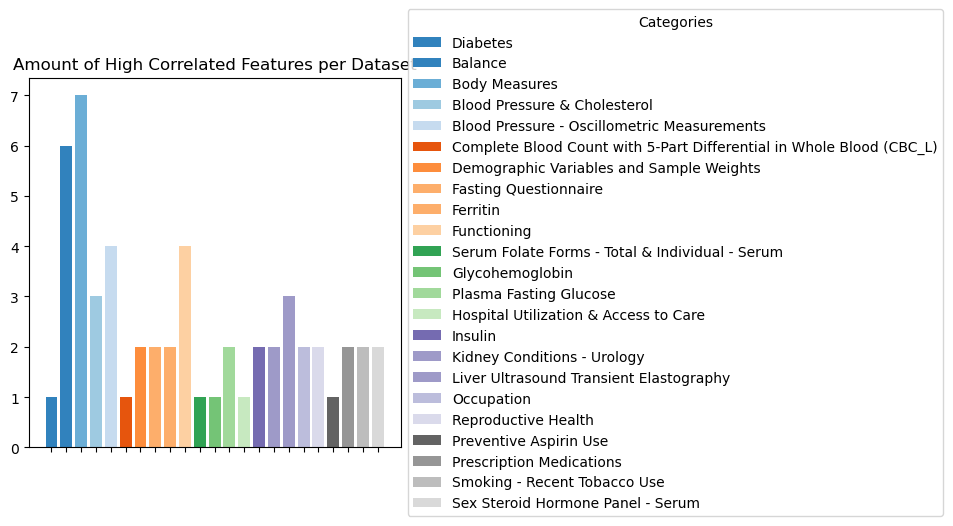

In [13]:
from matplotlib.cm import get_cmap
from matplotlib.patches import Patch

all_databases = []
for i in range(len(filtCorrs) - 1):
    all_databases.append(codeDict[filtCorrs[i][0]][0])

print(all_databases)

unique_db = []
for i in all_databases:
    if i not in unique_db:
        unique_db.append(i)

counts = []
for i in unique_db:
    counts.append(all_databases.count(i))

print(counts)

cmap = get_cmap('tab20c')
colors = [cmap(i / len(unique_db)) for i in range(len(unique_db))]

fig, ax = plt.subplots()
bars = ax.bar(range(len(counts)), counts, color=colors)

ax.set_xticks(range(len(unique_db)))
ax.set_xticklabels([''] * len(unique_db))

legend_elements = [Patch(facecolor=colors[i], label=unique_db[i]) for i in range(len(unique_db))]

# Shrink plot to make space for legend
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.75, box.height])

# Add legend outside to the right with multiple columns if needed
ax.legend(handles=legend_elements,
          title="Categories",
          loc='center left',
          bbox_to_anchor=(1, 0.5),
          ncol=1)  # You can set ncol=2 if many labels

plt.title('Amount of High Correlated Features per Dataset')

In [25]:
sorted_corrs = sorted(filtCorrs, key=lambda x: x[1], reverse=True)
top_10 = []
for i in range(0,10):
    feature = sorted_corrs[i][0]
    importance = sorted_corrs[i][1]
    top_10.append((codeDict[feature][1], importance))
print(top_10)

[('Take diabetic pills to lower blood sugar', 0.5050867887972069), ('MRT cond. 3, trial 2, reason stopped', 0.30846757299551536), ('MRT cond. 3, trial 2, time', 0.2853477113087644), ('Ever told you had high blood pressure', 0.2679558769582363), ('Taken prescription medicine, past month', 0.25801847498143854), ('Used last 5 days - Chewing tobacco', 0.24923684746459707), ('Taking meds to lower blood cholesterol?', 0.22463394141912343), ('# days smoked pipe over last 5 days', 0.22239388869990667), ('Dr told to take daily low-dose aspirin?', 0.19495141935742832), ('WG-SS Disability Indicator 18+', 0.18255462848194098)]


# Regressions

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Use the dataset with your identified correlated features
df = pd.read_csv('all_data.csv')

# Define target variable (1 for diabetes, 2 for no diabetes)
# We'll convert it to a binary format (0 for no diabetes, 1 for diabetes)
df_ml = df.copy()

# Filter out missing values in the target
df_ml = df_ml[df_ml['DIQ010'].isin([1, 2])]  # Keep only Yes/No answers
df_ml['diabetes'] = np.where(df_ml['DIQ010'] == 1, 1, 0)  # 1=Yes, 2=No in original data

# Select features with correlation > 0.2 (or use your filtCorrs list)
# Let's pick a subset of meaningful features based on your correlation analysis
#selected_features = [
#    'BMXBMI',            # Body Mass Index
#    'BMXWAIST',          # Waist Circumference
#    'BPQ020',            # High blood pressure history
#    'RIDAGEYR',          # Age in years
#    'LBXGH',             # Glycohemoglobin
#    'LBXGLU',            # Fasting Glucose
#    'LBXIN'              # Insulin
#]

# CONSTANCE - MESSING WITH DIFFERENT SELECTED FEATURES
selected_features = []
for i in range(len(filtCorrs) - 1):
    selected_features.append(filtCorrs[i][0])

# Display the selected dataset
print("Selected features shape:", df_ml[selected_features + ['diabetes']].shape)
df_ml[selected_features + ['diabetes']].head()

Selected features shape: (11452, 56)


,DIQ070,BAARFC11,BAXPF22,BAXTC32,BAARFC32,BAXTC41,BAXTC42,BMXWT,BMIHT,BMXBMI,...,RHQ031,RHD280,RXQ510,RXQ033,RXQ050,SMQ740,SMQ690D,LBXDHE,LBDDHESI,diabetes
0,NaN,NaN,NaN,NaN,NaN,13.0,17.0,86.9,NaN,27.0,...,NaN,NaN,2.0,1.0,1.0,NaN,NaN,49.2,1.330,0
1,NaN,NaN,NaN,NaN,NaN,25.0,30.0,101.8,NaN,33.5,...,NaN,NaN,2.0,1.0,1.0,NaN,NaN,27.6,0.748,0
2,1.0,NaN,NaN,NaN,NaN,2.0,1.0,69.4,NaN,29.7,...,1.0,2.0,1.0,1.0,1.0,NaN,NaN,101.0,2.740,1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.3,NaN,23.8,...,NaN,NaN,NaN,1.0,2.0,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.6,1.0,NaN,...,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,0


Initial data shape: (11452, 56)

Missing values by column:
DIQ070       9453
BAARFC11    11405
BAXPF22     11359
BAXTC32     11376
BAARFC32    11433
BAXTC41      7711
BAXTC42     10193
BMXWT        3060
BMIHT       11322
BMXBMI       3212
BMXARML      3218
BMXARMC      3223
BMXWAIST     3484
BMXHIP       4890
BPQ020       3229
BPQ080       3229
BPQ101D      3229
BPAOCSZ      4068
BPXOSY1      4158
BPXOSY2      4170
BPXOSY3      4195
LBXRDW       4084
RIDAGEYR        0
DMDHHSIZ        0
PHACOFHR    11423
PHACOFMN    11423
LBXFER       9533
LBDFERSI     9533
FNQ440       3584
FNQ490       3585
FNDADI       3583
FNDAEDI      3583
LBXSF6SI     4317
LBXGH        4960
LBXGLU       7910
LBDGLUSI     7910
HUQ010          0
LBXIN        8061
LBDINSI      8061
KIQ005       6418
KIQ481       6439
LUARXIN     11259
LUXSMED      4971
LUXCAPM      4972
OCD150       3242
OHQ845          1
RHQ031       8194
RHD280       8691
RXQ510       5982
RXQ033         21
RXQ050       5468
SMQ740      11427
SMQ69

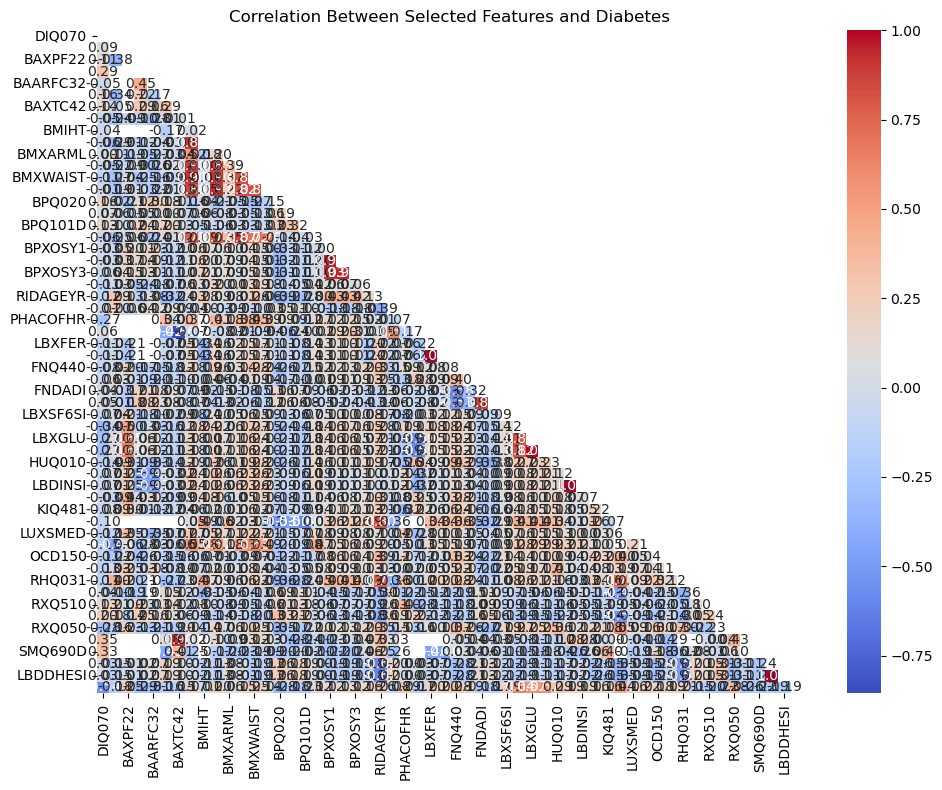

In [15]:
# Handling missing values and preprocessing
df_clean = df_ml[selected_features + ['diabetes']].copy()
print(f"Initial data shape: {df_clean.shape}")

# Check missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values by column:")
print(missing_values)

# Drop rows where too many features are missing (you may adjust this)
df_clean = df_clean.dropna(thresh=len(selected_features) // 2 + 2)  # Keep rows with at least half of features + target
print(f"After removing rows with too many missing values: {df_clean.shape}")

# Plot correlations of selected features
plt.figure(figsize=(10, 8))
corr = df_clean[selected_features + ['diabetes']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=mask)
plt.title('Correlation Between Selected Features and Diabetes')
plt.tight_layout()
plt.show()

In [18]:
# Split the data
X = df_clean[selected_features]
y = df_clean['diabetes']

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing for numeric columns (scaling)
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Create preprocessing and modeling pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the model
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['DIQ070', 'BAARFC11', 'BAXPF22', 'BAXTC32', 'BAARFC32', 'BAXTC41',
       'BAXTC42', 'BMXWT', 'BMIHT', 'BMXBMI', 'BMXARML', 'BMXARMC', 'BMXWAIST',
       'BMXHIP', 'BPQ020', 'BPQ080', 'BPQ101D', 'BPAOCSZ', 'BPXOSY...
       'PHACOFMN', 'LBXFER', 'LBDFERSI', 'FNQ440', 'FNQ490', 'FNDADI',
       'FNDAEDI', 'LBXSF6SI', 'LBXGH', 'LBXGLU', 'LBDGLUSI', 'HUQ010', 'LBXIN',
       'LBDINSI', 'KIQ005', 'KIQ481', 'LUARXIN', 'LUXSMED', 'LUXCAPM',
       'OCD150', 'OHQ845', 'RHQ031', 'RHD280', 'RXQ510', 'RXQ033', 'RXQ050',
       'SMQ740', 'SMQ690D', 'LBXDHE', 'LBDDHESI'],
      dtype='object'))])),
                ('classifier', LogisticRegression(random_state=42))])

Classification Accuracy: 0.9629

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1072
           1       0.90      0.81      0.86       167

    accuracy                           0.96      1239
   macro avg       0.94      0.90      0.92      1239
weighted avg       0.96      0.96      0.96      1239



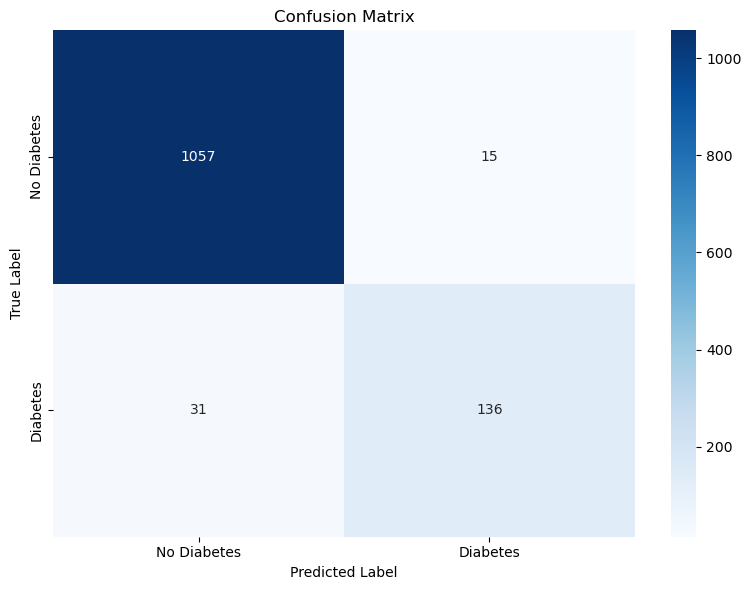

In [17]:
# Evaluate classification performance
y_pred = model_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 4956it [10:53,  7.46it/s]                          


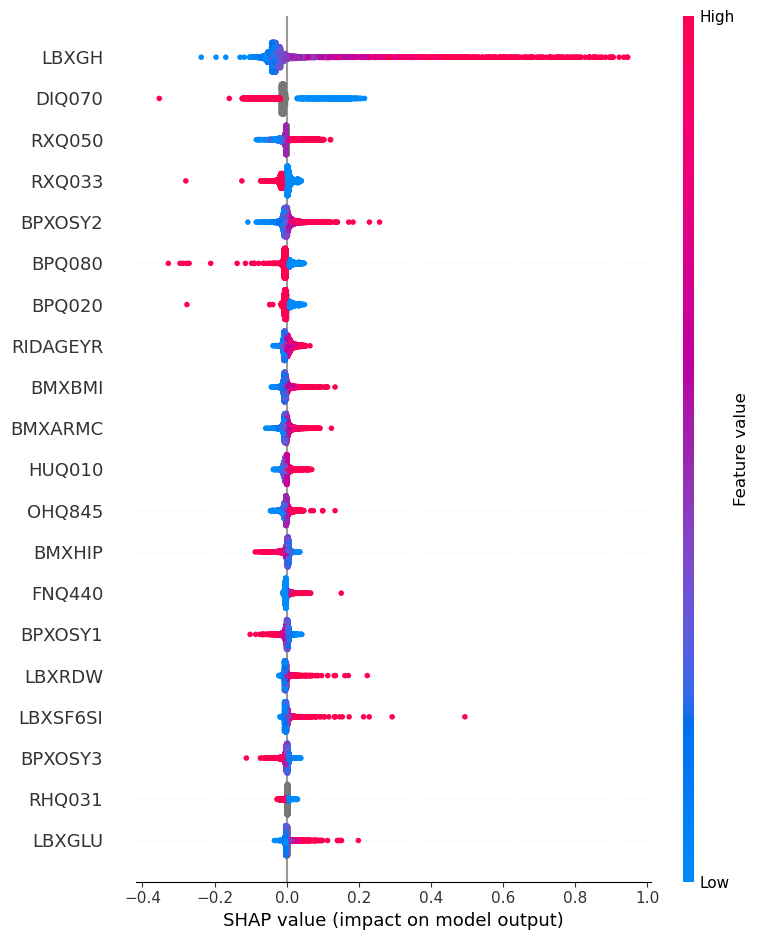

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (55, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [24]:
import shap

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    # you can add categorical preprocessing here too
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

pipeline.fit(X_train, y_train)

masker = shap.maskers.Independent(X_train)

# Wrap the pipeline's predict_proba function (or use a lambda)
explainer = shap.Explainer(pipeline.predict_proba, masker)

# Compute SHAP values for class 1 (positive class)
shap_values = explainer(X_train)

# Plot
shap.summary_plot(shap_values[..., 1], X_train)

## Supply SHAP with fitted model, also training data (basically for SHAP to learn features distributions)
#explainer = shap.Explainer(model_pipeline, X_train)
## Use explainer to compute the model's output values in test set
#shap_values = explainer(X_train)
#
shap.plots.waterfall(shap_values[5], max_display = 14)

In [31]:

# Extract SHAP values for class 1
shap_class1 = shap_values.values[:, :, 1]  # shape now (4955, 55)

# Create DataFrame
shap_df = pd.DataFrame(shap_class1, columns=X_train.columns)

# Compute mean absolute SHAP values
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

# Get top 10 features
top_10 = mean_abs_shap.head(10)
print(top_10)

log_feature_names = top_10.index.tolist()
log_top_10 = []
for i in range(0,10):
    feature = log_feature_names[i]
    log_top_10.append(codeDict[feature][1])
print(log_top_10)


LBXGH       0.073853
DIQ070      0.030180
RXQ050      0.018696
RXQ033      0.011940
BPXOSY2     0.011623
BPQ080      0.009933
BPQ020      0.009076
RIDAGEYR    0.008552
BMXBMI      0.008545
BMXARMC     0.007827
dtype: float64
['Glycohemoglobin (%)', 'Take diabetic pills to lower blood sugar', 'Number of prescription medicines taken', 'Taken prescription medicine, past month', 'Systolic - 2nd oscillometric reading', 'Doctor told you - high cholesterol level', 'Ever told you had high blood pressure', 'Age in years at screening', 'Body Mass Index (kg/m**2)', 'Arm Circumference (cm)']


In [61]:
# Try additional classifier models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
}

# Compare models
results = {}
for name, classifier in classifiers.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Perform cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = cv_scores
    
    print(f"{name} - Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Fit and predict
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} - Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print()

Logistic Regression - Cross-validation accuracy: 0.9617 ± 0.0075
Logistic Regression - Test accuracy: 0.9629

Random Forest - Cross-validation accuracy: 0.9653 ± 0.0085
Random Forest - Test accuracy: 0.9621



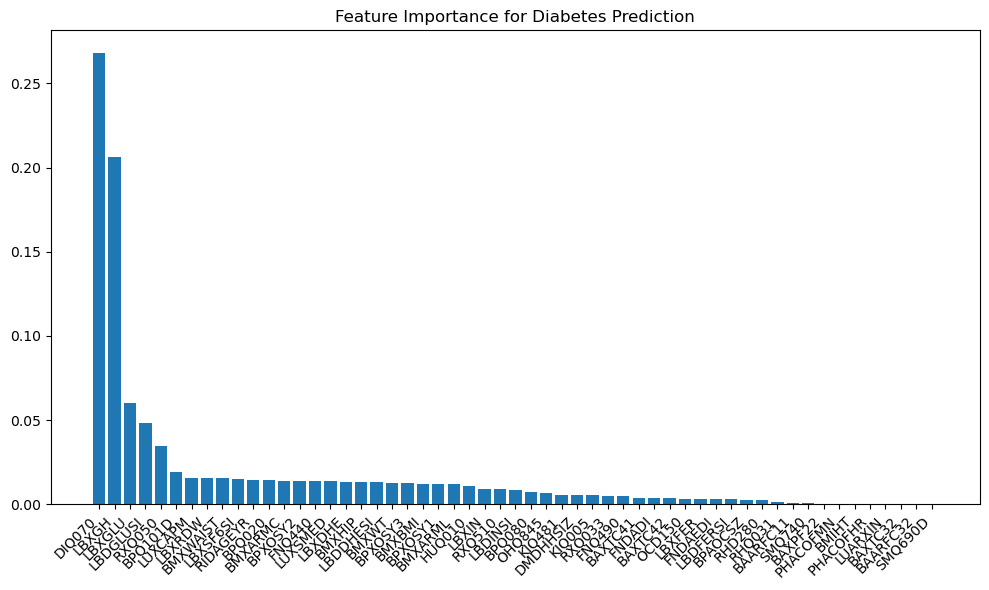

Feature Importance:
DIQ070: 0.2681
LBXGH: 0.2062
LBXGLU: 0.0603
LBDGLUSI: 0.0486
RXQ050: 0.0345
BPQ101D: 0.0195
LUXCAPM: 0.0159
LBXRDW: 0.0159
BMXWAIST: 0.0157
LBXSF6SI: 0.0152
RIDAGEYR: 0.0146
BPQ020: 0.0145
BMXARMC: 0.0141
BPXOSY2: 0.0138
FNQ440: 0.0138
LUXSMED: 0.0136
LBXDHE: 0.0135
BMXHIP: 0.0134
LBDDHESI: 0.0134
BMXWT: 0.0130
BPXOSY3: 0.0129
BMXBMI: 0.0124
BPXOSY1: 0.0123
BMXARML: 0.0119
HUQ010: 0.0109
LBXIN: 0.0091
RXQ510: 0.0089
LBDINSI: 0.0086
BPQ080: 0.0072
OHQ845: 0.0069
KIQ481: 0.0059
DMDHHSIZ: 0.0058
KIQ005: 0.0053
RXQ033: 0.0053
FNQ490: 0.0048
BAXTC41: 0.0039
FNDADI: 0.0037
BAXTC42: 0.0035
OCD150: 0.0035
LBXFER: 0.0034
FNDAEDI: 0.0033
LBDFERSI: 0.0030
BPAOCSZ: 0.0028
RHD280: 0.0025
RHQ031: 0.0014
BAARFC11: 0.0009
SMQ740: 0.0008
BAXPF22: 0.0004
PHACOFMN: 0.0003
BMIHT: 0.0003
PHACOFHR: 0.0002
LUARXIN: 0.0001
BAXTC32: 0.0001
BAARFC32: 0.0001
SMQ690D: 0.0000


In [62]:
# Feature importance analysis with Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])
rf_model.fit(X_train, y_train)

# Extract feature importance
rf_classifier = rf_model.named_steps['classifier']
feature_names = selected_features
feature_importance = rf_classifier.feature_importances_

# Sort features by importance
indices = np.argsort(feature_importance)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importance for Diabetes Prediction')
plt.bar(range(len(feature_importance)), feature_importance[indices], align='center')
plt.xticks(range(len(feature_importance)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print feature importance
print("Feature Importance:")
for i in indices:
    feature = feature_names[i]
    importance = feature_importance[i]
    print(f"{feature}: {importance:.4f}")

In [68]:
top_10 = []
for i in range(0,10):
    feature = feature_names[indices[i]]
    importance = feature_importance[i]
    top_10.append(codeDict[feature][1])
print(top_10)

['Take diabetic pills to lower blood sugar', 'Glycohemoglobin (%)', 'Fasting Glucose (mg/dL)', 'Fasting Glucose (mmol/L)', 'Number of prescription medicines taken', 'Taking meds to lower blood cholesterol?', 'Median CAP, decibels per meter (dB/m)', 'Red cell distribution width (%)', 'Waist Circumference (cm)', 'Mefox oxidation product (nmol/L)']


### Regression to predict Glycohemoglobin levels (LBXGH)

In [ ]:
# Define new target
if 'LBXGH' in df_ml.columns:
    # Filter out any missing values in the target
    df_reg = df_ml.dropna(subset=['LBXGH'])
    
    # Choose predictors (removing LBXGH from the features list)
    reg_features = [f for f in selected_features if f != 'LBXGH']
    
    # Add diabetes as a feature
    reg_features.append('diabetes')
    
    # Define X and y for regression
    X_reg = df_reg[reg_features]
    y_reg = df_reg['LBXGH']
    
    # Split data
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
    
    # Create a new preprocessor for regression using the columns in reg_features
    numeric_transformer_reg = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    reg_preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_reg, reg_features)
        ])
    
    # Create regression pipeline
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ])
    
    # Train regression model
    reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate regression performance
    y_reg_pred = reg_pipeline.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_reg_pred)
    r2 = r2_score(y_reg_test, y_reg_pred)
    
    print(f"Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R^2 Score: {r2:.4f}")
    
    # Plot actual vs predicted values
    plt.figure(figsize=(8, 8))
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Actual vs Predicted Glycohemoglobin Levels')
    plt.tight_layout()
    plt.show()

In [ ]:
# Add Linear Regression for Glycohemoglobin prediction
if 'LBXGH' in df_ml.columns:
    # Create a linear regression pipeline
    linear_reg_pipeline = Pipeline(steps=[
        ('preprocessor', reg_preprocessor),
        ('regressor', LinearRegression())
    ])
    
    # Train the linear regression model
    linear_reg_pipeline.fit(X_reg_train, y_reg_train)
    
    # Evaluate linear regression performance
    linear_y_pred = linear_reg_pipeline.predict(X_reg_test)
    linear_mse = mean_squared_error(y_reg_test, linear_y_pred)
    linear_r2 = r2_score(y_reg_test, linear_y_pred)
    
    print("\nLinear Regression for Glycohemoglobin (LBXGH) Prediction:")
    print(f"Mean Squared Error: {linear_mse:.4f}")
    print(f"R^2 Score: {linear_r2:.4f}")
    
    # Compare with Random Forest Regressor
    print("\nModel Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    
    # Visualize predictions from both models
    plt.figure(figsize=(12, 6))
    
    # Random Forest predictions
    plt.subplot(1, 2, 1)
    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5, color='blue')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Random Forest Predictions')
    
    # Linear Regression predictions
    plt.subplot(1, 2, 2)
    plt.scatter(y_reg_test, linear_y_pred, alpha=0.5, color='red')
    plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=2)
    plt.xlabel('Actual Glycohemoglobin')
    plt.ylabel('Predicted Glycohemoglobin')
    plt.title('Linear Regression Predictions')
    
    plt.tight_layout()
    plt.show()
    
    # Plot feature coefficients for linear model
    if hasattr(linear_reg_pipeline.named_steps['regressor'], 'coef_'):
        # Get coefficients
        coefficients = linear_reg_pipeline.named_steps['regressor'].coef_
        
        # Create a DataFrame for visualization
        coef_df = pd.DataFrame({
            'Feature': reg_features,
            'Coefficient': coefficients
        })
        
        # Sort by absolute coefficient value
        coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
        coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
        
        # Plot
        plt.figure(figsize=(10, 6))
        colors = ['red' if c < 0 else 'blue' for c in coef_df['Coefficient']]
        plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors)
        plt.xticks(rotation=45, ha='right')
        plt.title('Linear Regression Coefficients')
        plt.ylabel('Coefficient Value')
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Print feature coefficients with descriptions when available
        print("\nLinear Regression Coefficients:")
        for feature, coef in zip(reg_features, coefficients):
            print(f"{feature}: {coef:.4f}")
    
    # Update the model summary cell to include linear regression
    print("\nUpdated Model Comparison:")
    print(f"Random Forest R^2: {r2:.4f}")
    print(f"Linear Regression R^2: {linear_r2:.4f}")
    print(f"Difference: {abs(r2 - linear_r2):.4f}")

In [ ]:
# Model Summary
print(f"1. Classification Models (Diabetes Prediction):")
print(f"   - Random Forest:       {results['Random Forest'].mean():.4f} ± {results['Random Forest'].std():.4f}")
print(f"   - Logistic Regression: {results['Logistic Regression'].mean():.4f} ± {results['Logistic Regression'].std():.4f}")
print(f"   - Best model accuracy:  {max([results[model].mean() for model in results]):.4f}")

print(f"\n2. Top features for diabetes prediction (by importance):")
for i in indices[:3]:
    feature = feature_names[i]
    print(f"   - {feature}: {feature_importance[i]:.4f}")

print(f"\n3. Classification Performance:")
print(f"   - Precision for diabetes detection: {classification_report(y_test, y_pred).split()[11]}")
print(f"   - Recall for diabetes detection:    {classification_report(y_test, y_pred).split()[12]}")
print(f"   - F1-score for diabetes detection:  {classification_report(y_test, y_pred).split()[13]}")

if 'LBXGH' in df_ml.columns:
    print(f"\n4. Glycohemoglobin Regression Models:")
    print(f"   - Random Forest R^2:       {r2:.4f}")
    print(f"   - Linear Regression R^2:   {linear_r2:.4f}")
    print(f"   - Mean Squared Error:     {mse:.4f}")